# 06: Final report

Joins the per-record metric CSVs (`02`-`05`) on `(dataset, target, model, query_id, difficulty)`, aggregates, renders figures, and writes `eval/reports/final.md`. Results are reported **per target in dedicated sections** (`SQL -> Cypher`, `SQL -> AQL`, `SQL -> Gremlin`); no table or figure averages across targets. Execution columns are optional (absent until notebook 05 has run).

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / "pyproject.toml").exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT / "eval"))

from datetime import datetime

import pandas as pd
from harness import (
    FIGURES_DIR,
    FINAL_REPORT_MD,
    METRICS_BEHAVIOURAL_CSV,
    METRICS_DISTANCE_CSV,
    METRICS_EXECUTION_CSV,
    METRICS_STRUCTURAL_CSV,
    plots,
)

FIGURES_DIR.mkdir(parents=True, exist_ok=True)


## Load and join metric CSVs

In [2]:
beh = pd.read_csv(METRICS_BEHAVIOURAL_CSV)
stru = pd.read_csv(METRICS_STRUCTURAL_CSV)
dist = pd.read_csv(METRICS_DISTANCE_CSV)
execm = pd.read_csv(METRICS_EXECUTION_CSV) if METRICS_EXECUTION_CSV.exists() else None

key = ['dataset','target','model','query_id','difficulty']
df = beh.merge(stru, on=key, how='outer').merge(dist, on=key, how='outer')
if execm is not None:
    exec_key = [k for k in key if k in execm.columns]
    # Only bring in execution-specific columns; drop columns already present
    # (e.g. validation_passed) so the merge does not create _x/_y collisions.
    exec_cols = exec_key + [c for c in execm.columns if c not in df.columns]
    df = df.merge(execm[exec_cols], on=exec_key, how='left')
print(f'Joined rows: {len(df)}')
df.head(5)

Joined rows: 180


,dataset,target,model,provider,query_id,difficulty,validation_passed,pass_at_1,iterations_used,duration_seconds,...,reference_error,translated_runtime_s,execution_error,execution_accuracy,result_precision,result_recall,result_f1,result_jaccard_dist,reference_rows,translated_rows
0,ldbc,aql,claude-opus-4-8,anthropic,ldbc_q01,easy,True,True,1,3.278285,...,NaN,0.008599,NaN,1.0,1.0,1.0,1.0,0.0,1,1
1,ldbc,aql,claude-opus-4-8,anthropic,ldbc_q02,easy,True,True,1,2.613209,...,NaN,0.118763,NaN,1.0,1.0,1.0,1.0,0.0,12932,12932
2,ldbc,aql,claude-opus-4-8,anthropic,ldbc_q03,easy,True,True,1,4.596436,...,NaN,0.006061,NaN,1.0,1.0,1.0,1.0,0.0,4,4
3,ldbc,aql,claude-opus-4-8,anthropic,ldbc_q04,hard,True,True,1,2.334190,...,NaN,14.473389,NaN,1.0,1.0,1.0,1.0,0.0,10,10
4,ldbc,aql,claude-opus-4-8,anthropic,ldbc_q05,hard,True,True,1,3.771293,...,NaN,114.353099,NaN,1.0,1.0,1.0,1.0,0.0,20,20


In [3]:
# Shared axes/columns. Results are split per target so targets are never averaged
# together; MODELS/QUERIES are derived from the data (never hardcoded).
MODELS = plots.model_axis(df)
QUERIES = plots.query_axis(df)
COMP_COLS = plots.COMPONENT_F1_COLS
TARGETS = [t for t in ['cypher', 'aql', 'gremlin'] if t in set(df['target'])]
TARGET_LABEL = {'cypher': 'SQL -> Cypher', 'aql': 'SQL -> AQL', 'gremlin': 'SQL -> Gremlin'}
HAS_EXEC = execm is not None and 'execution_accuracy' in df.columns
print(f'{len(MODELS)} model(s): {MODELS}')
print(f'{len(QUERIES)} query id(s): {QUERIES}')
print(f'Targets in report: {TARGETS}')

4 model(s): ['claude-opus-4-8', 'gemma4:26b', 'llama3.2:latest', 'qwen3-coder:30b']
15 query id(s): ['ldbc_q01', 'ldbc_q02', 'ldbc_q03', 'ldbc_q04', 'ldbc_q05', 'ldbc_q06', 'ldbc_q07', 'ldbc_q08', 'ldbc_q09', 'ldbc_q10', 'ldbc_q11', 'ldbc_q12', 'ldbc_q13', 'ldbc_q14', 'ldbc_q15']
Targets in report: ['cypher', 'aql', 'gremlin']


## Headline numbers per matrix cell

In [4]:
group = ['dataset','target','model']
headline = pd.DataFrame()
headline['validation_pass_rate'] = df.groupby(group)['validation_passed'].mean()
headline['pass@1'] = df.groupby(group)['pass_at_1'].mean()
headline['component_f1'] = df.groupby(group)['component_f1_overall'].mean()
headline['normalized_ted'] = df.groupby(group)['normalized_ted'].mean()
if execm is not None and 'execution_accuracy' in df.columns:
    headline['execution_accuracy'] = df.groupby(group)['execution_accuracy'].mean()
    headline['result_f1'] = df.groupby(group)['result_f1'].mean()
headline

validation_pass_rate    pass@1  component_f1  \
dataset target  model                                                           
ldbc    aql     claude-opus-4-8              1.000000  1.000000      0.883675   
                gemma4:26b                   1.000000  0.933333      0.875839   
                llama3.2:latest              0.800000  0.466667      0.547494   
                qwen3-coder:30b              1.000000  1.000000      0.821752   
        cypher  claude-opus-4-8              1.000000  1.000000      0.980390   
                gemma4:26b                   1.000000  1.000000      0.981477   
                llama3.2:latest              1.000000  0.866667      0.823287   
                qwen3-coder:30b              1.000000  1.000000      0.925120   
        gremlin claude-opus-4-8              1.000000  1.000000      0.907426   
                gemma4:26b                   1.000000  0.933333      0.909241   
                llama3.2:latest              0.200000  0.200000      0.653274   
                qwen3-coder:30b              0.733333  0.666667      0.826638   

                                 normalized_ted  execution_accuracy  result_f1  
dataset target  model                                                           
ldbc    aql     claude-opus-4-8        0.224506            0.933333   0.933333  
                gemma4:26b             0.226171            0.933333   0.933333  
                llama3.2:latest        0.414359            0.000000   0.000000  
                qwen3-coder:30b        0.325791            0.466667   0.466667  
        cypher  claude-opus-4-8        0.066173            1.000000   1.000000  
                gemma4:26b             0.050576            1.000000   1.000000  
                llama3.2:latest        0.404789            0.200000   0.208120  
                qwen3-coder:30b        0.210969            0.533333   0.563676  
        gremlin claude-opus-4-8        0.347667            0.533333   0.557669  
                gemma4:26b             0.237387            0.666667   0.767455  
                llama3.2:latest        0.757825            0.000000   0.000000  
                qwen3-coder:30b        0.608045            0.200000   0.221002

## Stratified tables

In [5]:
primary = ['validation_passed','pass_at_1','component_f1_overall','normalized_ted']
if execm is not None and 'execution_accuracy' in df.columns:
    primary += ['execution_accuracy','result_f1']
by_cell = df.groupby(group)[primary].mean()
_bd = df.copy()
_bd['difficulty'] = pd.Categorical(_bd['difficulty'], ['easy','medium','hard'], ordered=True)
by_diff = _bd.groupby(['target','difficulty'], observed=True)[primary].mean()
print('By dataset x target x model:')
display(by_cell)
print('By target x difficulty:')
display(by_diff)

By dataset x target x model:


validation_passed  pass_at_1  \
dataset target  model                                           
ldbc    aql     claude-opus-4-8           1.000000   1.000000   
                gemma4:26b                1.000000   0.933333   
                llama3.2:latest           0.800000   0.466667   
                qwen3-coder:30b           1.000000   1.000000   
        cypher  claude-opus-4-8           1.000000   1.000000   
                gemma4:26b                1.000000   1.000000   
                llama3.2:latest           1.000000   0.866667   
                qwen3-coder:30b           1.000000   1.000000   
        gremlin claude-opus-4-8           1.000000   1.000000   
                gemma4:26b                1.000000   0.933333   
                llama3.2:latest           0.200000   0.200000   
                qwen3-coder:30b           0.733333   0.666667   

                                 component_f1_overall  normalized_ted  \
dataset target  model                                                   
ldbc    aql     claude-opus-4-8              0.883675        0.224506   
                gemma4:26b                   0.875839        0.226171   
                llama3.2:latest              0.547494        0.414359   
                qwen3-coder:30b              0.821752        0.325791   
        cypher  claude-opus-4-8              0.980390        0.066173   
                gemma4:26b                   0.981477        0.050576   
                llama3.2:latest              0.823287        0.404789   
                qwen3-coder:30b              0.925120        0.210969   
        gremlin claude-opus-4-8              0.907426        0.347667   
                gemma4:26b                   0.909241        0.237387   
                llama3.2:latest              0.653274        0.757825   
                qwen3-coder:30b              0.826638        0.608045   

                                 execution_accuracy  result_f1  
dataset target  model                                           
ldbc    aql     claude-opus-4-8            0.933333   0.933333  
                gemma4:26b                 0.933333   0.933333  
                llama3.2:latest            0.000000   0.000000  
                qwen3-coder:30b            0.466667   0.466667  
        cypher  claude-opus-4-8            1.000000   1.000000  
                gemma4:26b                 1.000000   1.000000  
                llama3.2:latest            0.200000   0.208120  
                qwen3-coder:30b            0.533333   0.563676  
        gremlin claude-opus-4-8            0.533333   0.557669  
                gemma4:26b                 0.666667   0.767455  
                llama3.2:latest            0.000000   0.000000  
                qwen3-coder:30b            0.200000   0.221002

By target x difficulty:


validation_passed  pass_at_1  component_f1_overall  \
target  difficulty                                                       
aql     easy                 1.000000   1.000000              0.937577   
        medium               0.937500   0.937500              0.818152   
        hard                 0.937500   0.750000              0.705938   
cypher  easy                 1.000000   0.916667              0.956282   
        medium               1.000000   1.000000              0.925783   
        hard                 1.000000   0.968750              0.917694   
gremlin easy                 0.916667   0.916667              0.923131   
        medium               0.750000   0.750000              0.793710   
        hard                 0.656250   0.593750              0.802242   

                    normalized_ted  execution_accuracy  result_f1  
target  difficulty                                                 
aql     easy              0.038357            0.750000   0.750000  
        medium            0.314779            0.562500   0.562500  
        hard              0.386427            0.531250   0.531250  
cypher  easy              0.078618            0.833333   0.833333  
        medium            0.238072            0.562500   0.562500  
        hard              0.194845            0.687500   0.705529  
gremlin easy              0.312756            0.500000   0.578758  
        medium            0.581749            0.312500   0.312500  
        hard              0.506338            0.312500   0.351462

## Plots: per target (Cypher and AQL kept separate)

Each target gets its own subsection. Every figure groups by `model` within a single target (never across targets) and is written with a target prefix (`cypher_*`, `aql_*`). Missing metrics (e.g. execution before notebook 05 runs, or a model run one-at-a-time) show grey `n/a` cells, never a false zero. These figures are embedded per-target in `final.md`.

In [6]:
def render_report(sub, prefix, label):
    plots.render_target(sub, prefix, label, plots.FIGURE_SETS['report'], FIGURES_DIR)


### SQL → Cypher

SQL -> Cypher: 4 model(s), 15 query id(s)


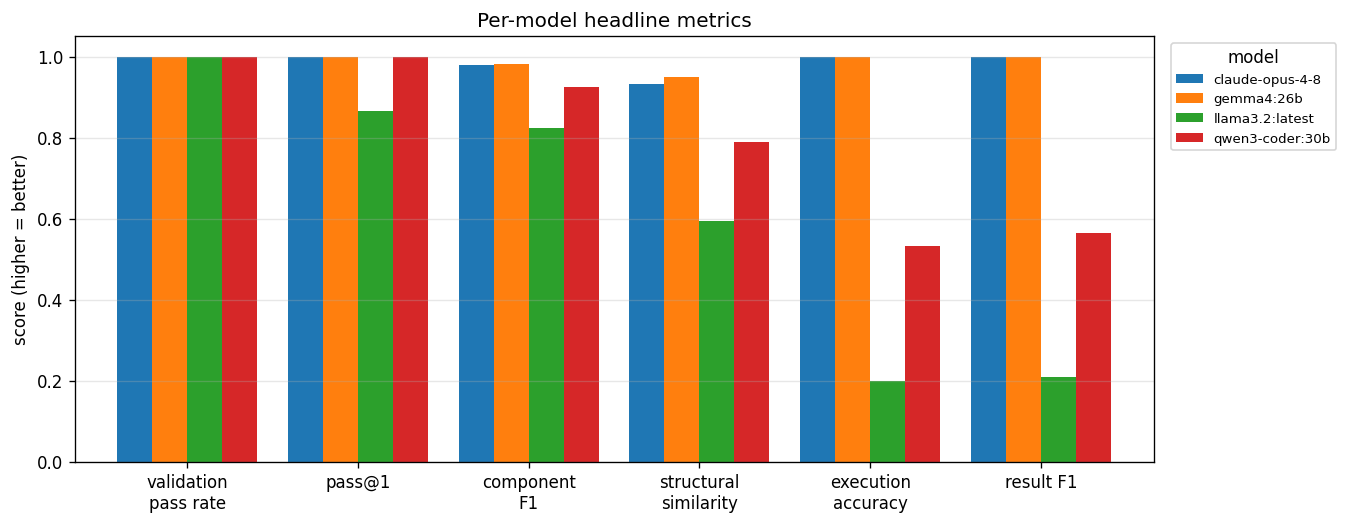

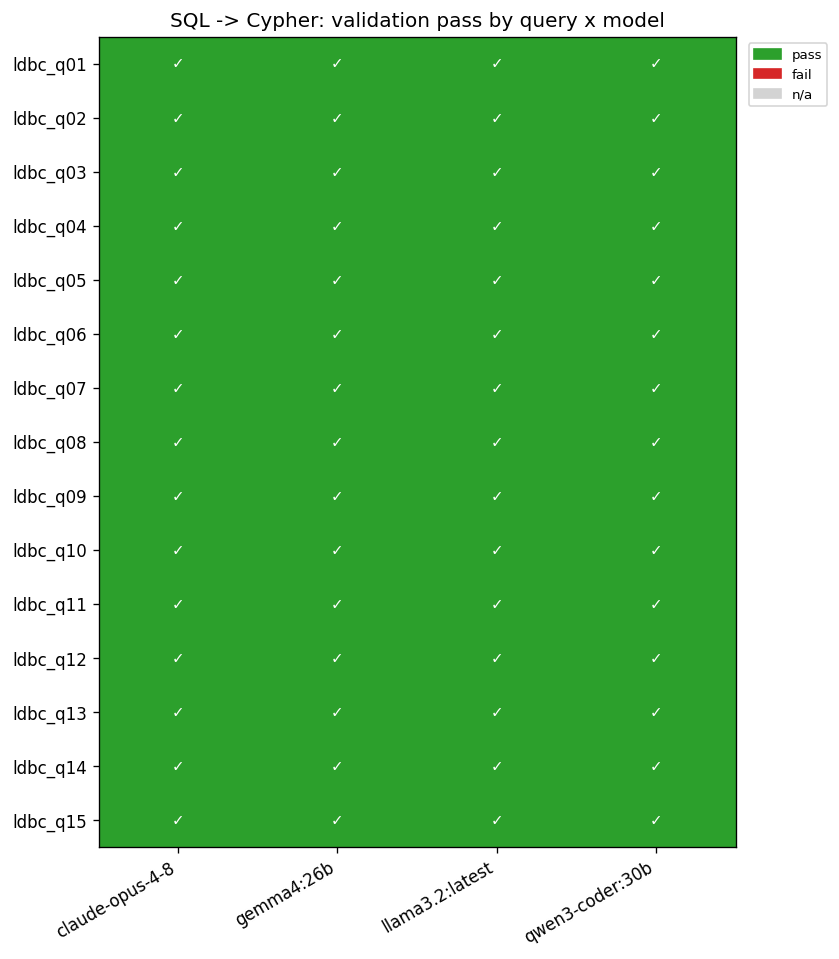

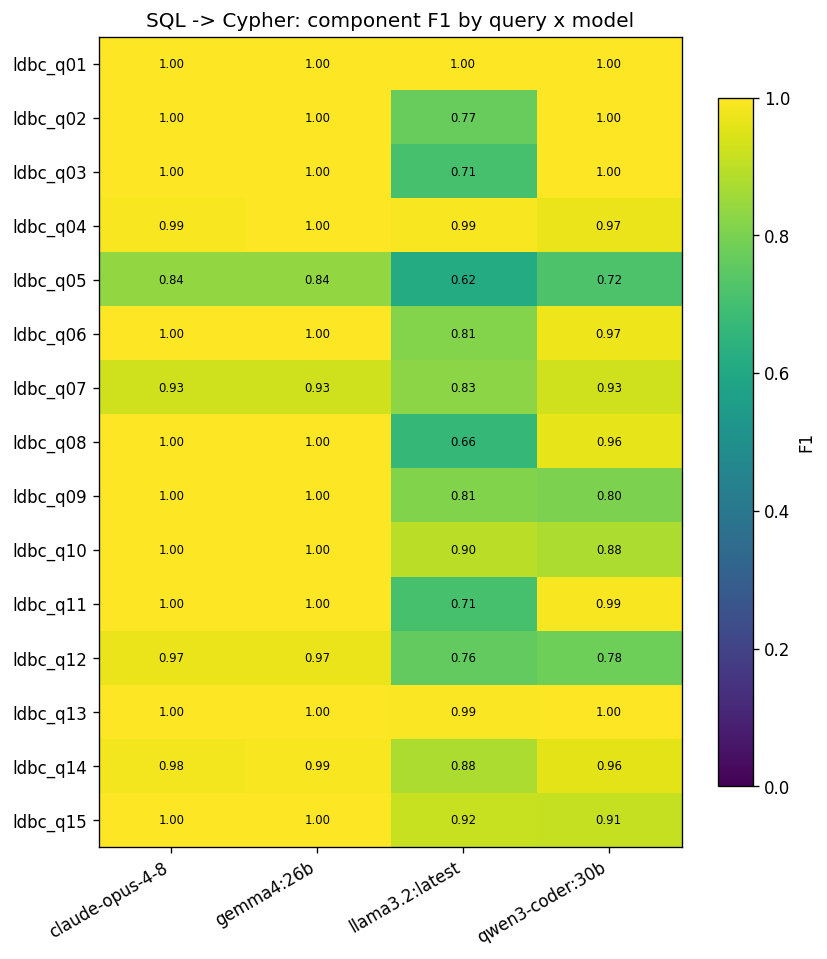

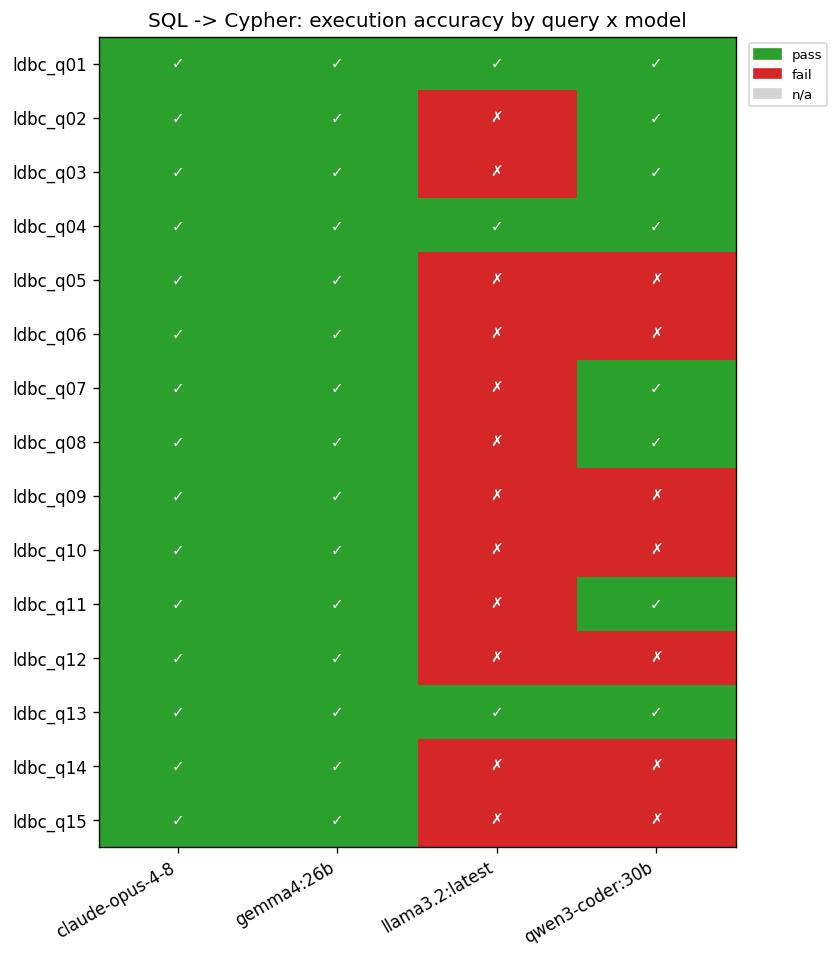

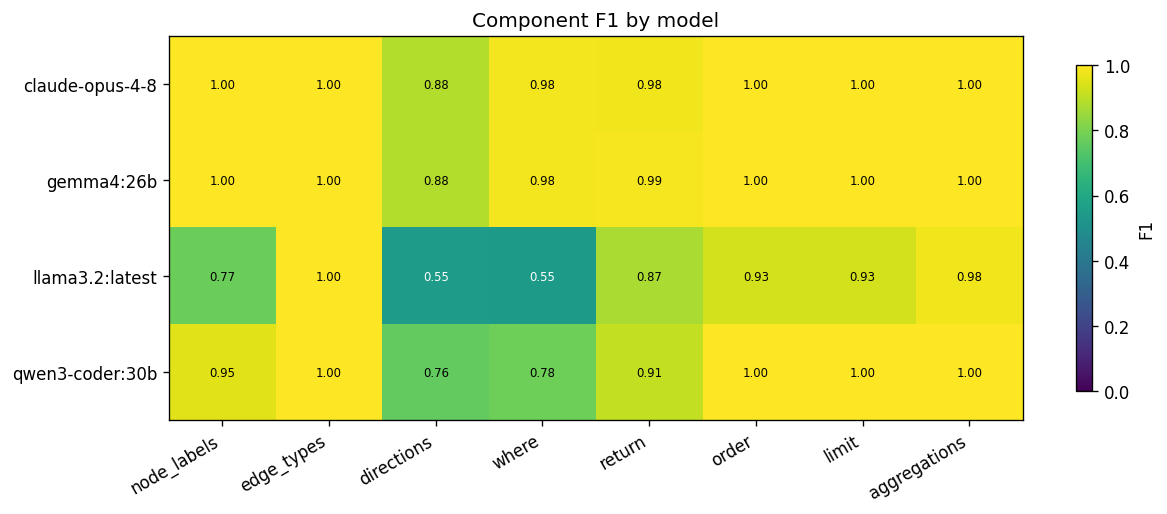

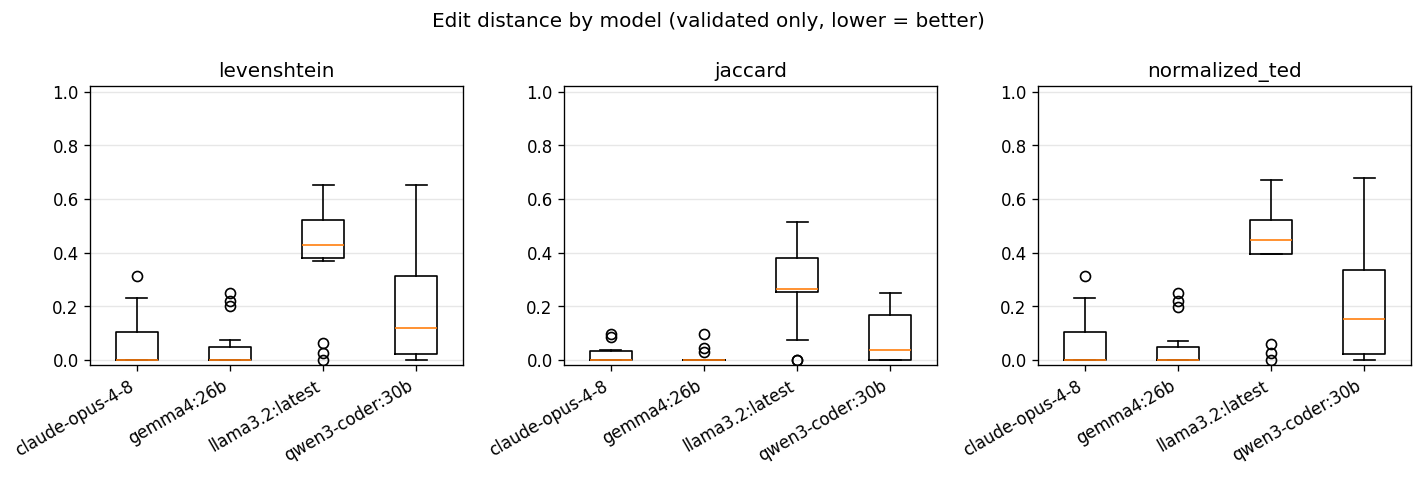

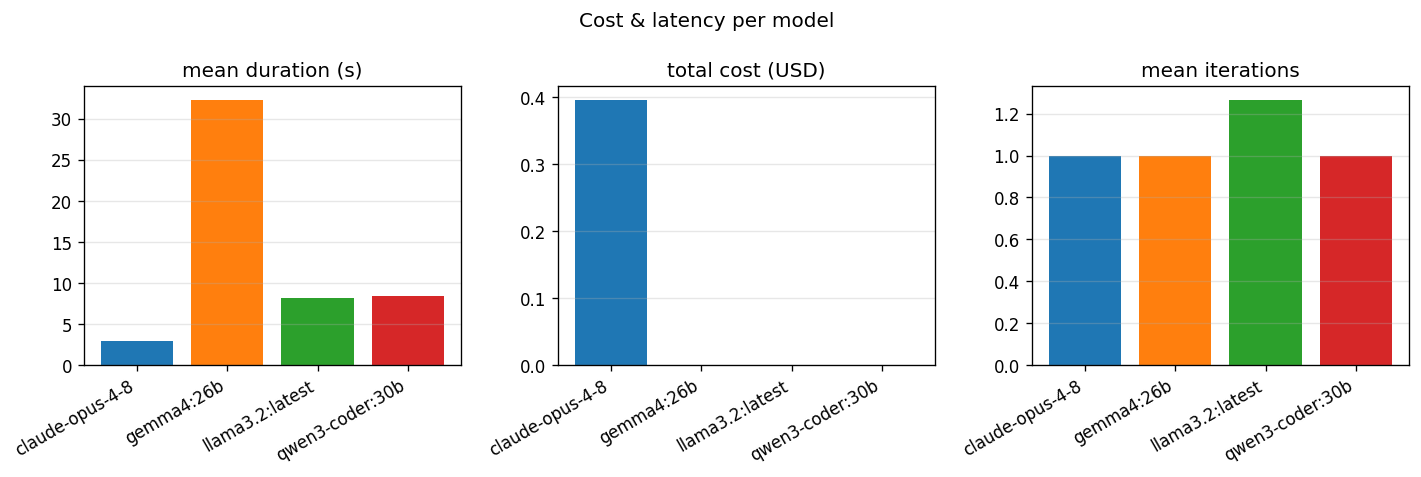

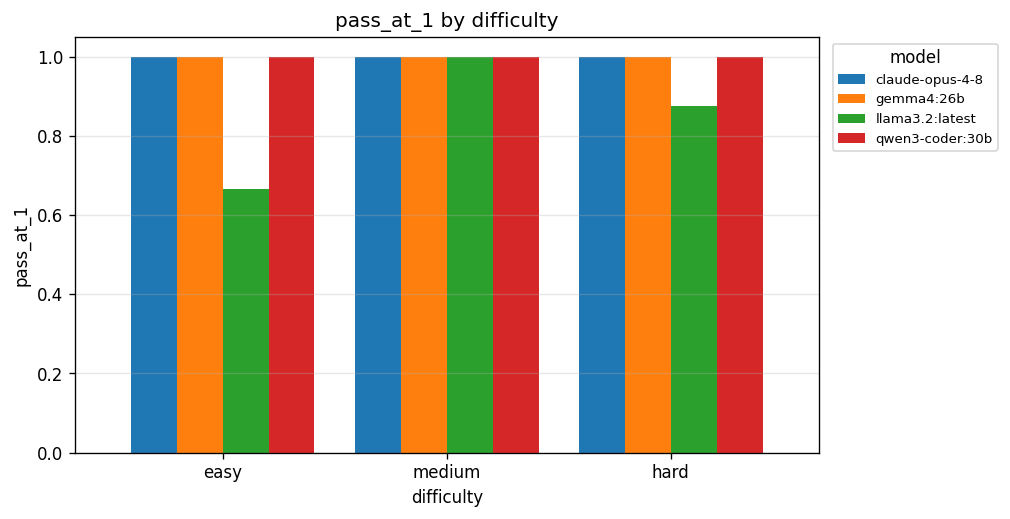

In [7]:
render_report(df[df['target'] == 'cypher'], 'cypher', 'SQL -> Cypher')

### SQL → AQL

SQL -> AQL: 4 model(s), 15 query id(s)


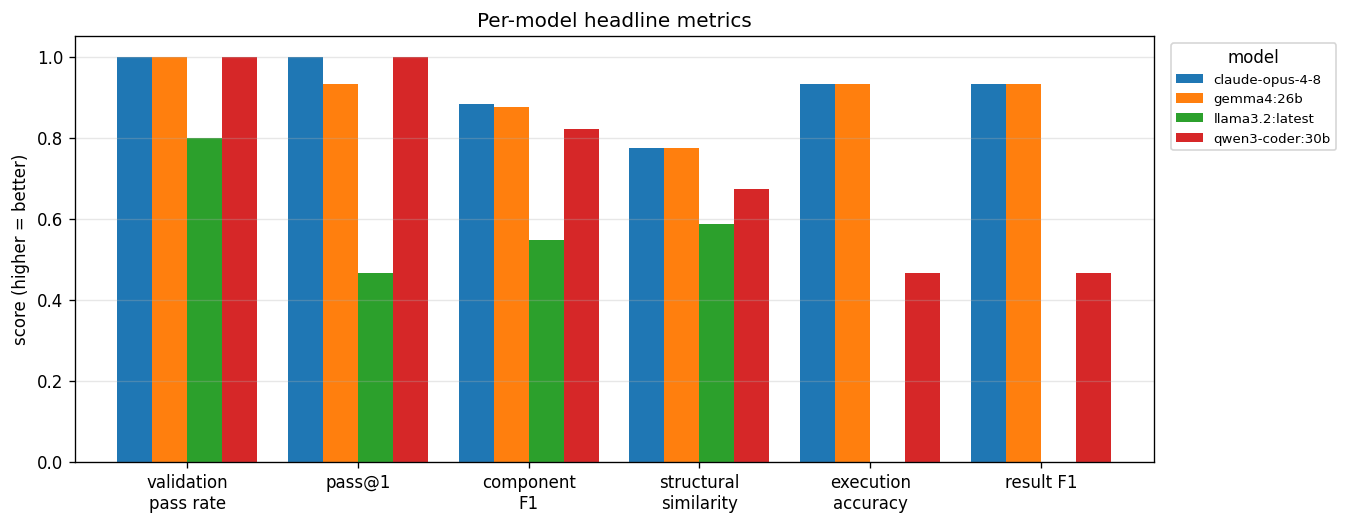

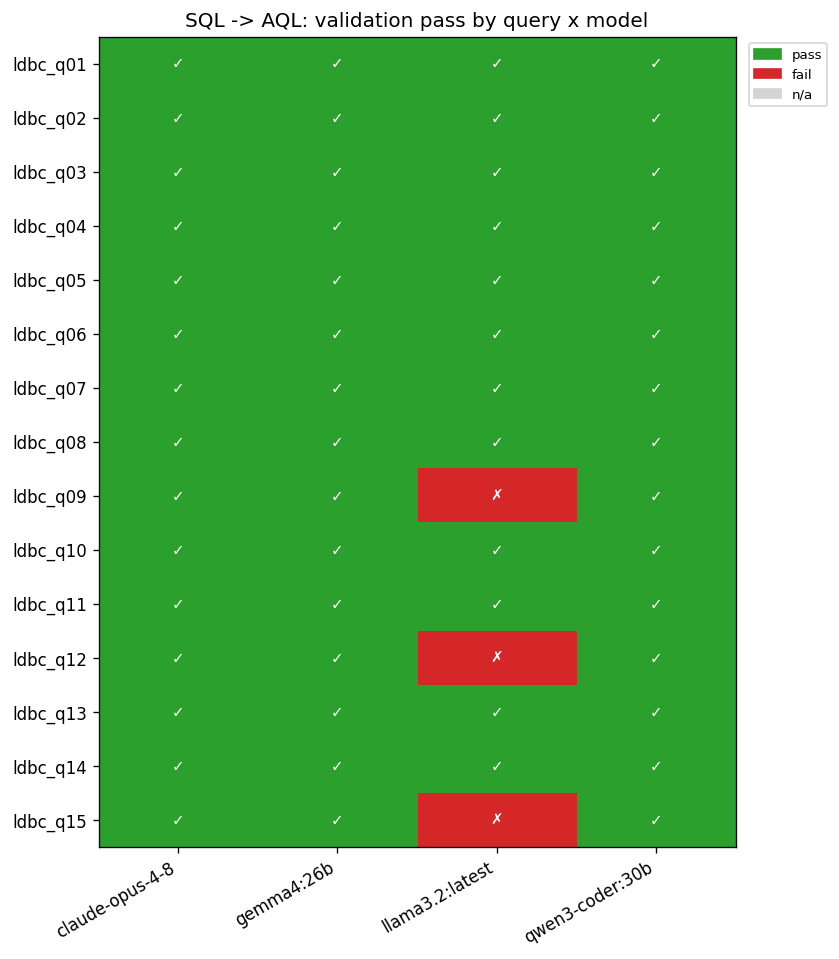

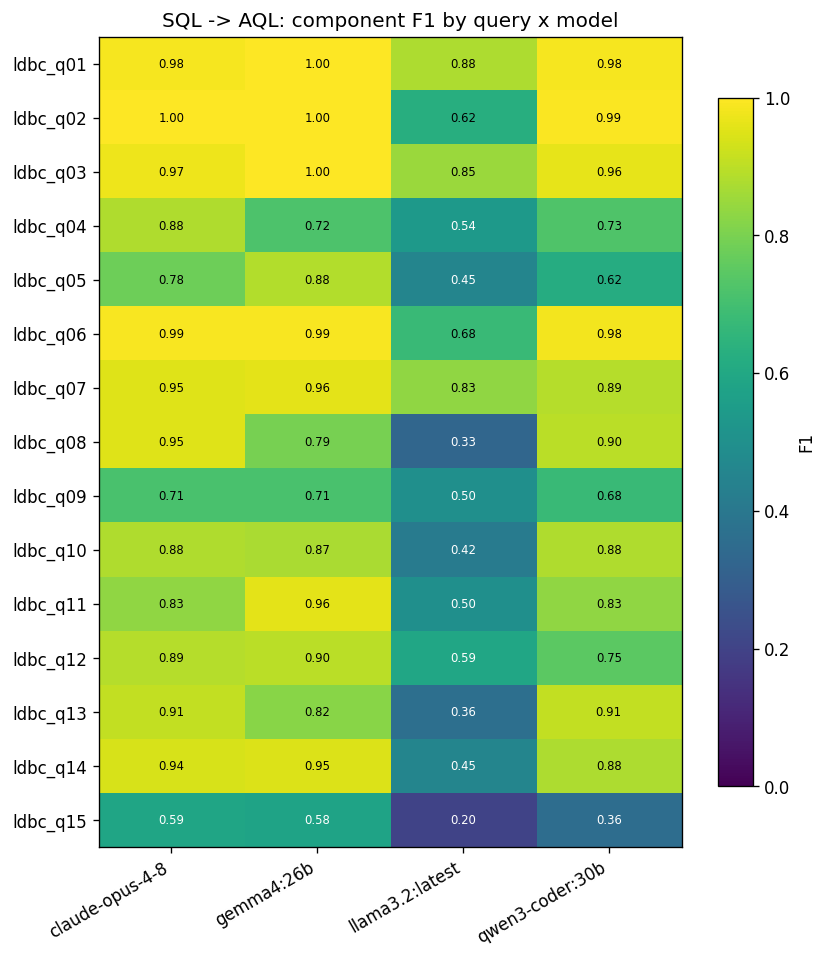

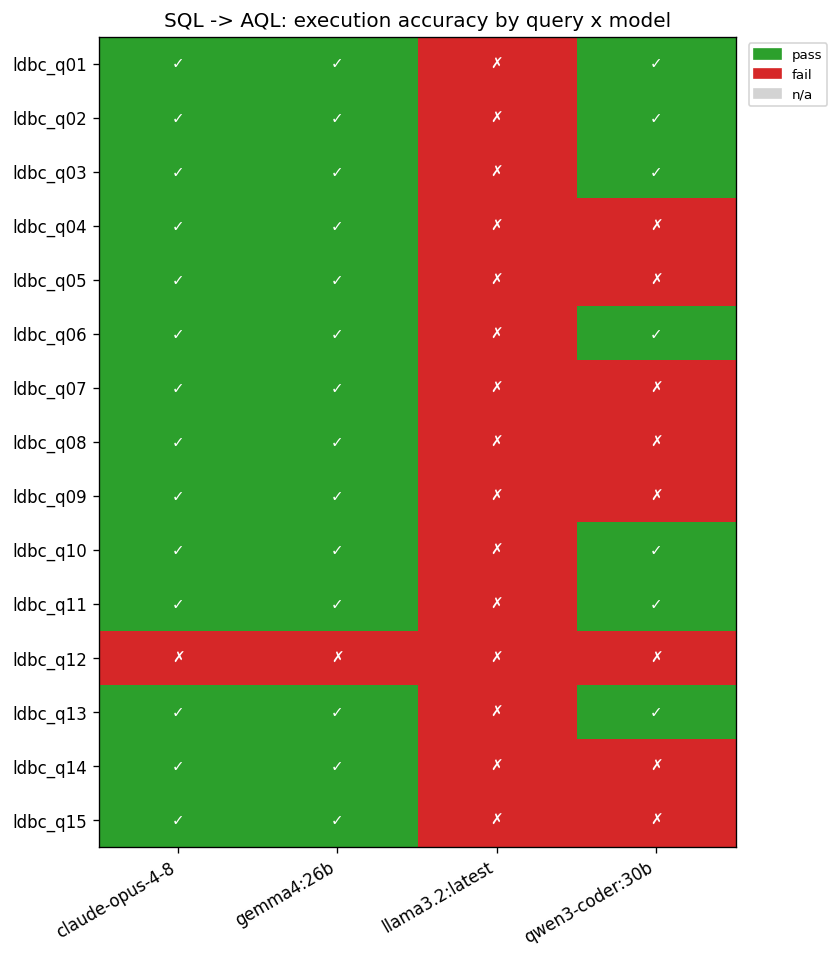

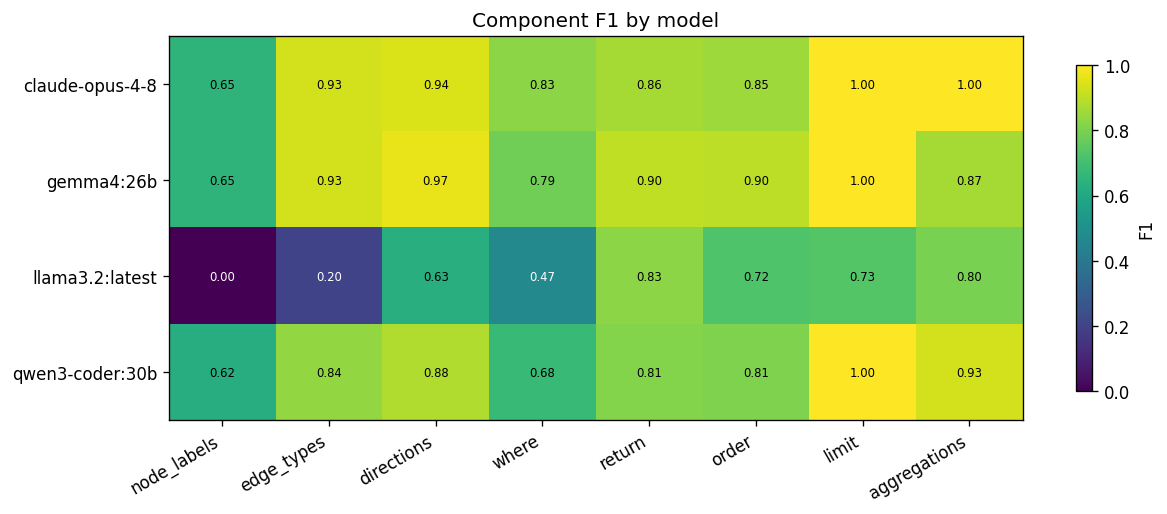

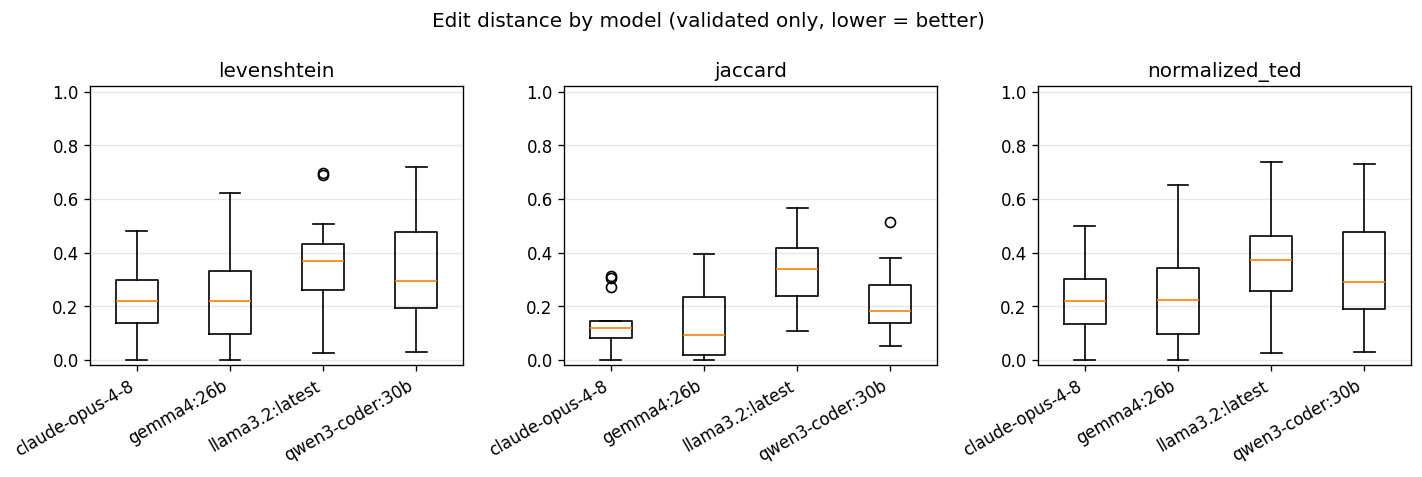

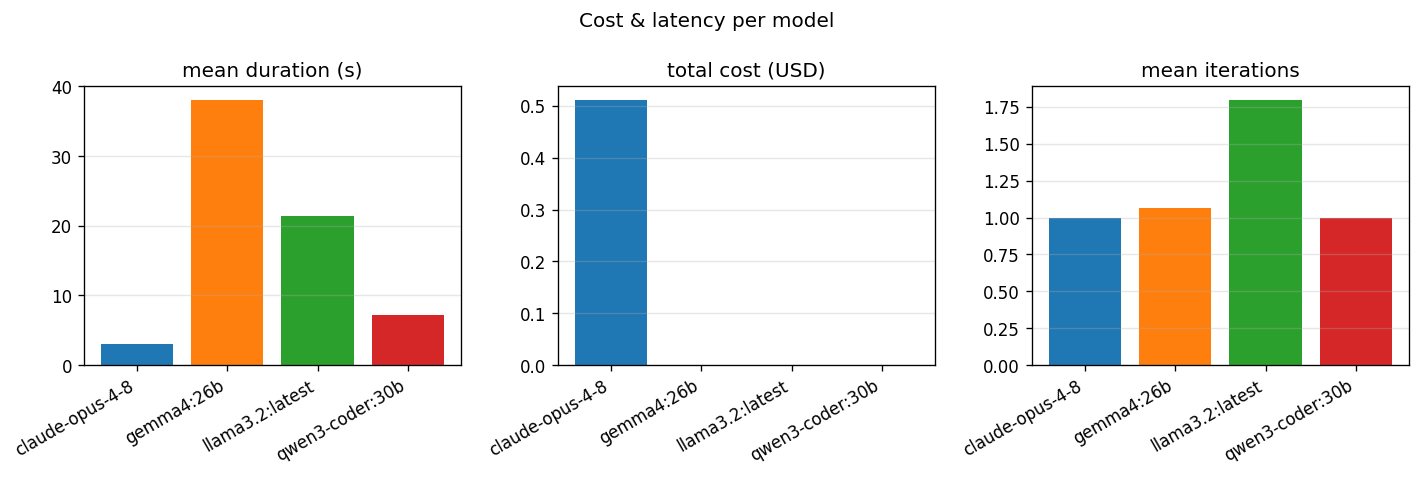

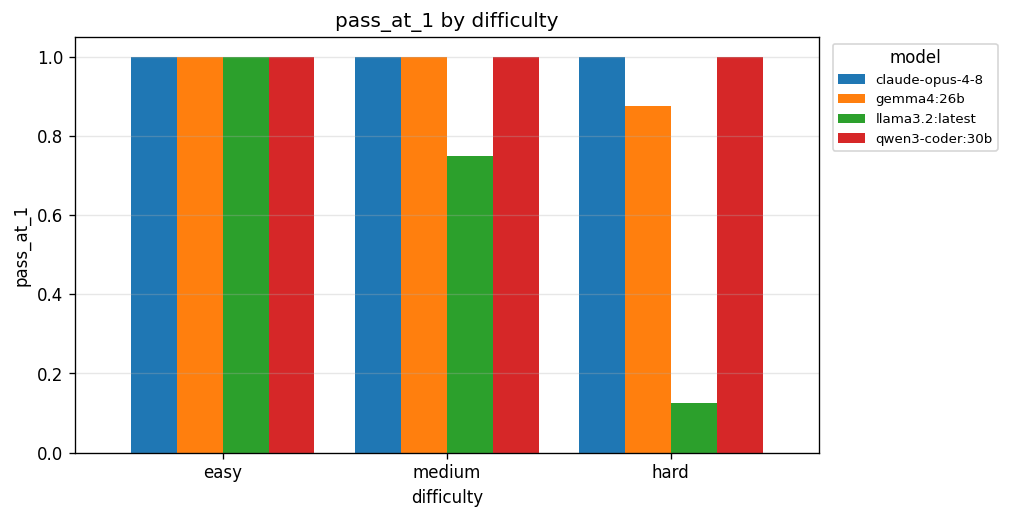

In [8]:
render_report(df[df['target'] == 'aql'], 'aql', 'SQL -> AQL')

### SQL → Gremlin

SQL -> Gremlin: 4 model(s), 15 query id(s)


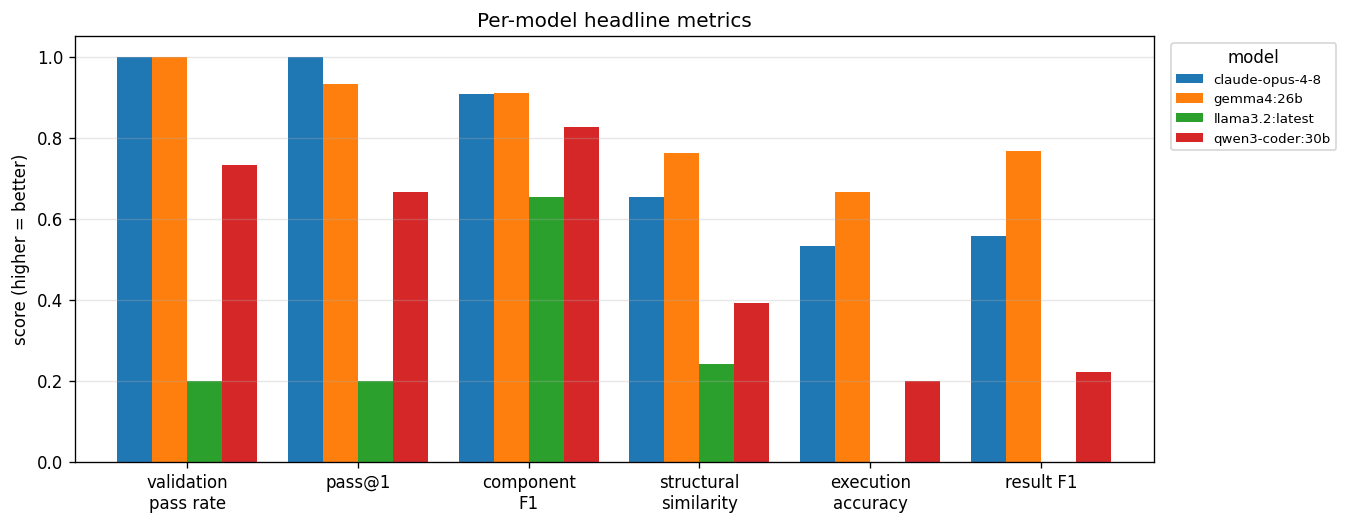

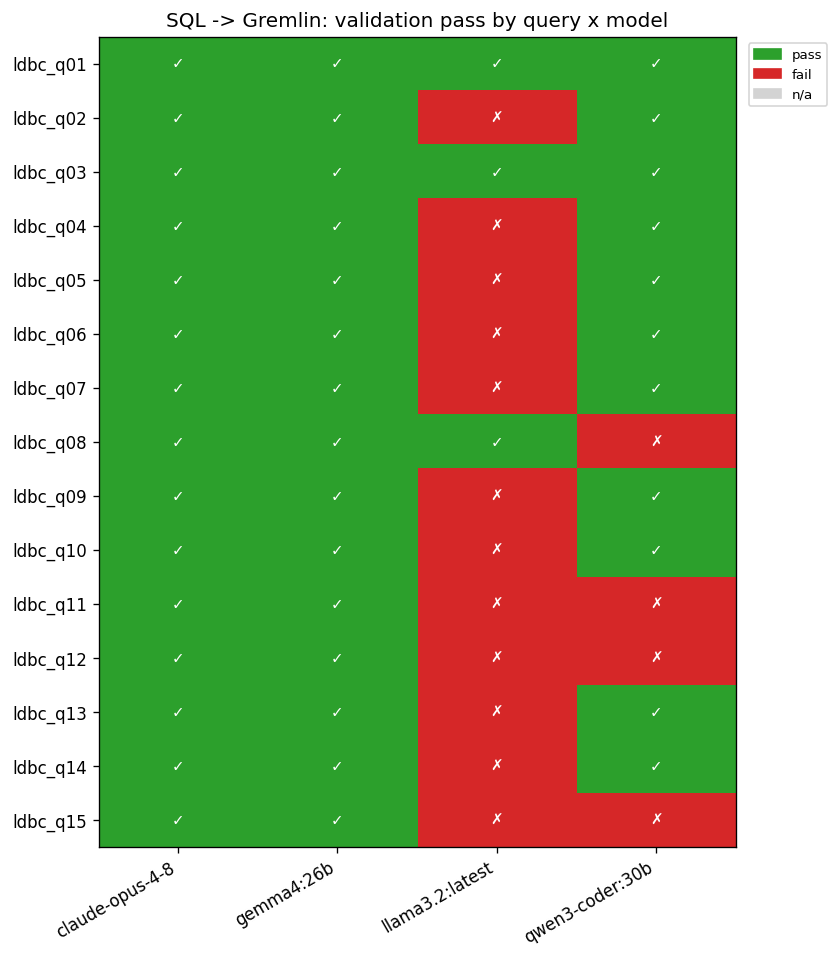

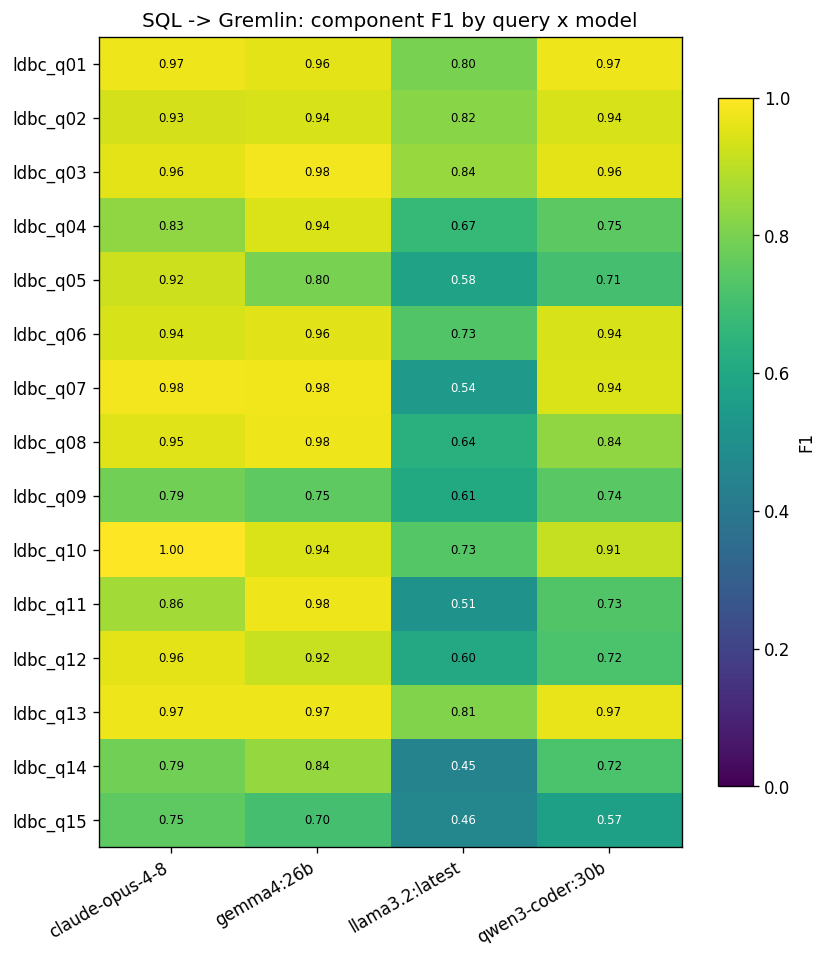

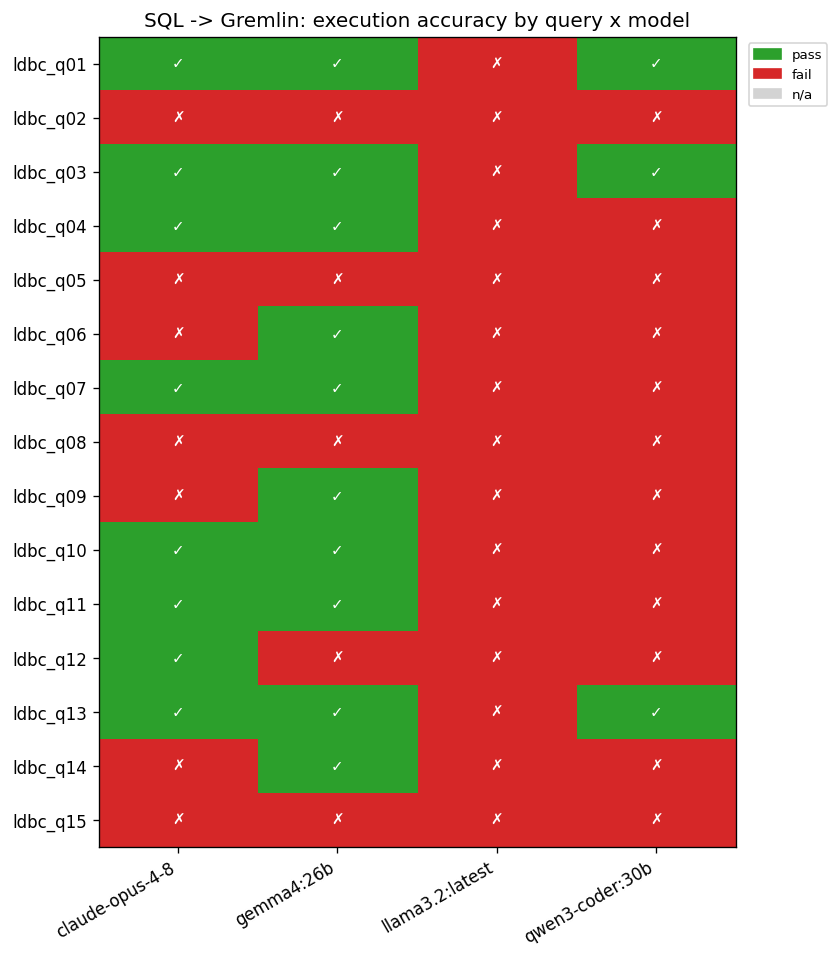

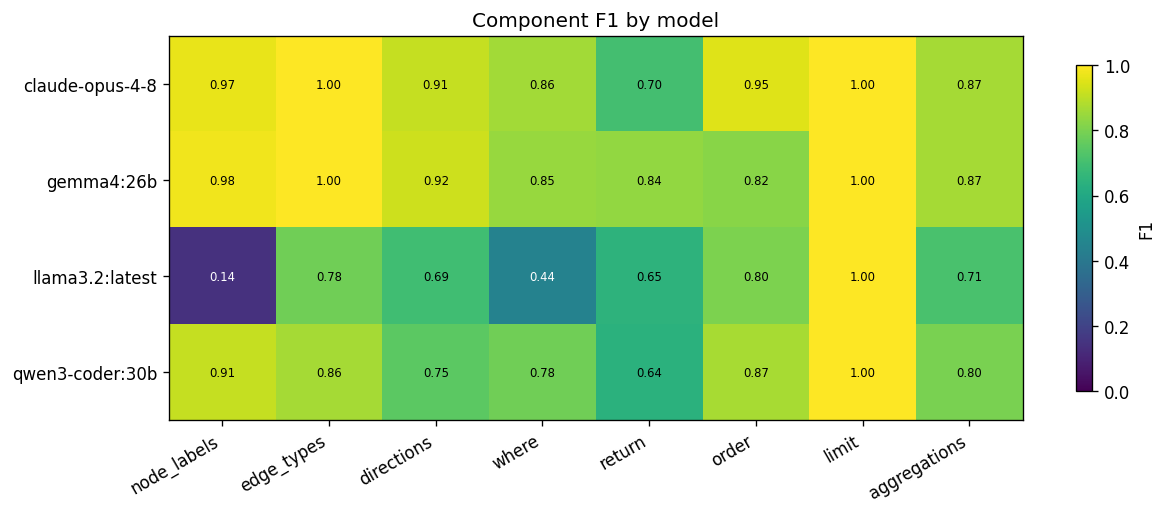

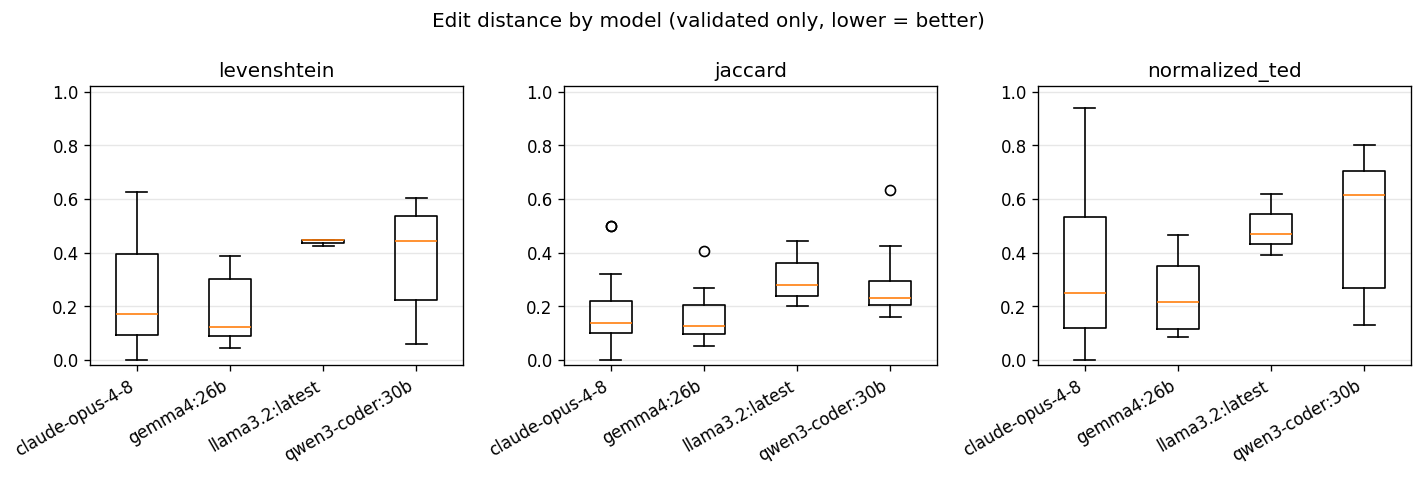

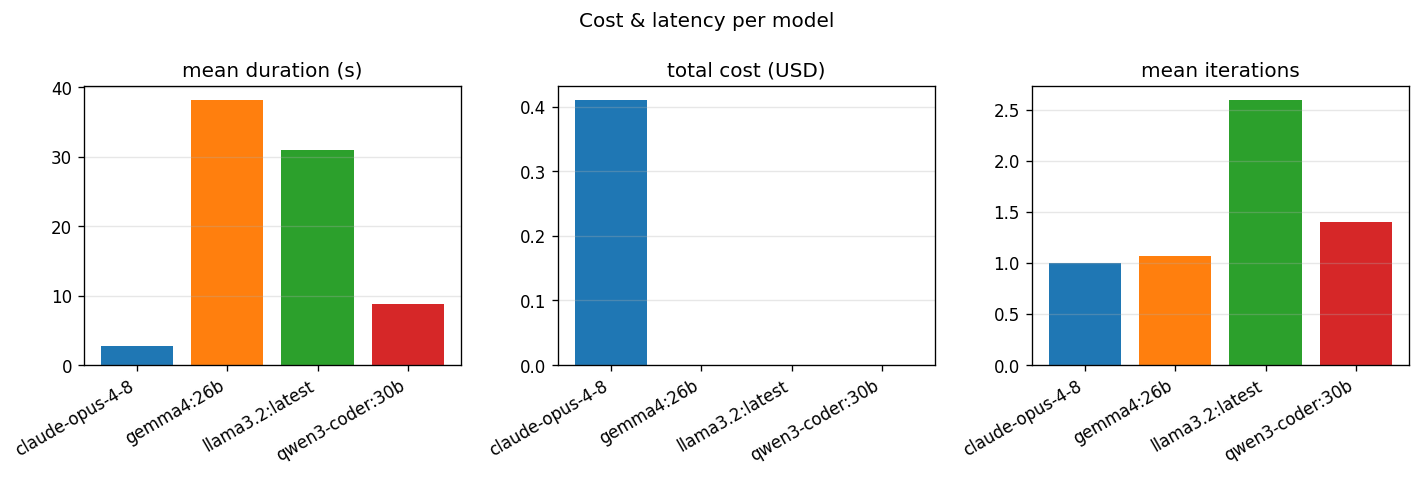

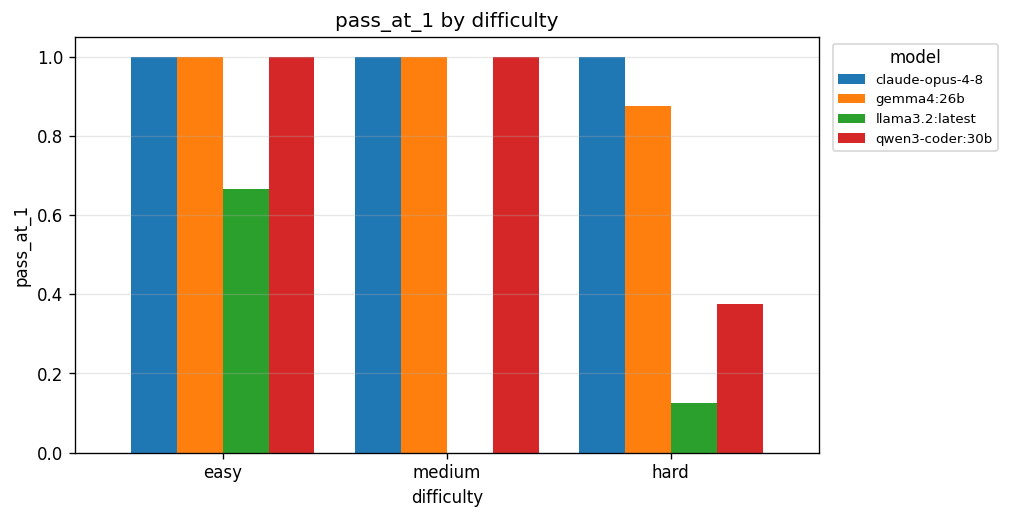

In [9]:
render_report(df[df['target'] == 'gremlin'], 'gremlin', 'SQL -> Gremlin')

## Failure list for manual error-taxonomy annotation

In [10]:
failure_mask = ~df['validation_passed'].astype(bool)
if execm is not None and 'execution_accuracy' in df.columns:
    failure_mask = failure_mask | (df['execution_accuracy'].fillna(1.0) < 1.0)
fcols = ['dataset','target','model','query_id','difficulty','validation_passed',
         'component_f1_overall','normalized_ted']
failures = df[failure_mask][fcols].copy()
failures['category'] = ''
failures['notes'] = ''
failures = failures.sort_values(['dataset','target','query_id']).reset_index(drop=True)
print(f'{len(failures)} failure cases to classify.')
failures.head(20)

83 failure cases to classify.


,dataset,target,model,query_id,difficulty,validation_passed,component_f1_overall,normalized_ted,category,notes
0,ldbc,aql,llama3.2:latest,ldbc_q01,easy,True,0.875000,0.023256,,
1,ldbc,aql,llama3.2:latest,ldbc_q02,easy,True,0.625000,0.076923,,
2,ldbc,aql,llama3.2:latest,ldbc_q03,easy,True,0.850000,0.064516,,
3,ldbc,aql,llama3.2:latest,ldbc_q04,hard,True,0.537500,0.392157,,
4,ldbc,aql,qwen3-coder:30b,ldbc_q04,hard,True,0.725379,0.645161,,
5,ldbc,aql,llama3.2:latest,ldbc_q05,hard,True,0.454246,0.544118,,
6,ldbc,aql,qwen3-coder:30b,ldbc_q05,hard,True,0.618659,0.542857,,
7,ldbc,aql,llama3.2:latest,ldbc_q06,medium,True,0.679487,0.436364,,
8,ldbc,aql,llama3.2:latest,ldbc_q07,medium,True,0.834135,0.342466,,
9,ldbc,aql,qwen3-coder:30b,ldbc_q07,medium,True,0.890476,0.246377,,


## Write the final markdown report

In [11]:
from tabulate import tabulate


def md_table(d, floatfmt='.3f'):
    return tabulate(d.reset_index(), headers='keys', tablefmt='github', floatfmt=floatfmt, showindex=False)

# Per-target table builders (one target only -- never averaged across targets).
def _headline(sub):
    h = pd.DataFrame(index=pd.Index(plots.model_axis(sub), name='model'))
    h['validation_pass_rate'] = sub.groupby('model')['validation_passed'].mean()
    h['pass@1'] = sub.groupby('model')['pass_at_1'].mean()
    h['component_f1'] = sub.groupby('model')['component_f1_overall'].mean()
    h['normalized_ted'] = sub.groupby('model')['normalized_ted'].mean()
    if HAS_EXEC:
        h['execution_accuracy'] = sub.groupby('model')['execution_accuracy'].mean()
        h['result_f1'] = sub.groupby('model')['result_f1'].mean()
    return h

def _by_diff(sub):
    s = sub.copy()
    s['difficulty'] = pd.Categorical(s['difficulty'], ['easy','medium','hard'], ordered=True)
    cols = ['validation_passed','pass_at_1','component_f1_overall','normalized_ted']
    if HAS_EXEC:
        cols += ['execution_accuracy','result_f1']
    return s.groupby('difficulty', observed=True)[cols].mean()

def _cost_latency(sub):
    if 'duration_seconds' not in sub.columns:
        return None
    return pd.DataFrame({
        'mean_duration_s': sub.groupby('model')['duration_seconds'].mean(),
        'total_cost_usd': sub.groupby('model')['cost_usd'].sum(),
        'mean_iterations': sub.groupby('model')['iterations_used'].mean(),
    }).reindex(plots.model_axis(sub))

def _failures(sub):
    mask = ~sub['validation_passed'].astype(bool)
    if HAS_EXEC:
        mask = mask | (sub['execution_accuracy'].fillna(1.0) < 1.0)
    fcols = ['model','query_id','difficulty','validation_passed','component_f1_overall','normalized_ted']
    f = sub[mask][fcols].copy()
    f['category'] = ''
    f['notes'] = ''
    return f.sort_values(['query_id','model']).reset_index(drop=True)

REPORT_FIGS = [
    ('Per-model headline metrics', 'model_headline.png'),
    ('Pass / fail by query x model', 'query_model_pass.png'),
    ('Component F1 by query x model', 'query_model_f1.png'),
    ('Execution accuracy by query x model', 'query_model_exec.png'),
    ('Component F1 per model', 'component_f1.png'),
    ('Edit distance by model', 'distance_by_model.png'),
    ('Cost & latency per model', 'cost_latency.png'),
    ('Pass rate by difficulty', 'passrate_by_difficulty.png'),
]

def target_section(sub, prefix, label):
    out = [f'\n## {label}\n']
    out.append(f'Translations: **{len(sub)}** ({int(sub["validation_passed"].sum())} validated)\n')
    out.append('\n### Headline (per model)\n')
    out.append(md_table(_headline(sub)) + '\n')
    out.append('\n### Stratified by difficulty\n')
    out.append(md_table(_by_diff(sub)) + '\n')
    out.append('\n### Component F1 breakdown (per model)\n')
    out.append(md_table(sub.groupby('model')[COMP_COLS].mean().reindex(plots.model_axis(sub))) + '\n')
    cl = _cost_latency(sub)
    if cl is not None:
        out.append('\n### Cost & latency (per model)\n')
        out.append(md_table(cl) + '\n')
    out.append('\n### Figures\n')
    out.extend(
        f'![{label}: {_title}](figures/{prefix}_{_fn})\n'
        for _title, _fn in REPORT_FIGS
        if (FIGURES_DIR / f'{prefix}_{_fn}').exists()
    )
    out.append('\n### Error taxonomy (fill in manually)\n')
    out.append('Categories: schema_error, hallucination, direction_error, predicate_error, '
               'projection_error, aggregation_error, join_to_path_error, other.\n\n')
    out.append(md_table(_failures(sub), floatfmt='.2f') + '\n')
    return '\n'.join(out)

total_records = len(df)
validated = int(df['validation_passed'].sum())
total_in = int(df['billed_input_tokens'].sum()) if 'billed_input_tokens' in df.columns else (int(df['input_tokens'].sum()) if 'input_tokens' in df.columns else 0)
total_out = int(df['output_tokens'].sum()) if 'output_tokens' in df.columns else 0
total_cost = float(df['cost_usd'].sum()) if 'cost_usd' in df.columns else 0.0

parts = []
parts.append('# rows2graph evaluation report\n')
parts.append(f'Generated: {datetime.now().isoformat(timespec="seconds")}\n')
parts.append(f'Models under evaluation: **{", ".join(MODELS)}**\n')
parts.append(f'Targets: **{", ".join(TARGET_LABEL.get(t, t) for t in TARGETS)}**\n')
parts.append(f'Total translations: **{total_records}** ({validated} validated)\n')
parts.append(f'Total tokens: **{total_in:,}** input / **{total_out:,}** output, approx **${total_cost:,.2f}** USD\n')
parts.append('\nResults are reported per target below; Cypher and AQL are never combined in one table or figure.\n')

# One dedicated section per target.
parts.extend(target_section(df[df['target'] == t], t, TARGET_LABEL.get(t, t)) for t in TARGETS)

if HAS_EXEC:
    parts.append('\n## Execution-metric caveats\n')
    parts.append('Oracle = gold SQL on Postgres vs generated query on the graph DB (multiset compare).\n\n')
    parts.append('- Query timeout: each generated query runs under a **180s per-query ceiling** (`EVAL_QUERY_TIMEOUT`); a query killed at the ceiling scores 0 even if it would return the correct rows given more time. This was raised from an earlier 120s so a correct-but-slow AQL translation is not scored as a failure for engine speed rather than translation quality. Verified example: `claude-opus-4-8` q05 (AQL) is a **correct** translation but runs ~123s -- it materialises full documents into arrays instead of counting with `RETURN 1`, so it was killed at 120s and passes at 180s (execution accuracy 0.857 -> 0.929, tied with gemma4:26b). `translated_runtime_s` still records per-query speed, so slow-but-correct queries stay visible.\n')
    parts.append('- Date reconciliation: Neo4j stores creationDate/birthday/joinDate as native temporals; ArangoDB stores them as ISO-8601 strings; Postgres uses timestamp/date. The comparator canonicalises the date columns (identified from the Postgres oracle) to epoch-millis on all sides.\n')
    parts.append('- AQL empty text: ArangoDB returns absent optional text (e.g. image-post content) as "" where Postgres has NULL; the AQL path reconciles the two.\n')
    parts.append('- Unified edges: AQL execution needs the mapping-aligned SCREAMING_SNAKE edge collections built by eval/scripts/build_arango_unified_edges.py; without them AQL traversals error and score 0.\n')
    parts.append('- Vacuous matches: when both stores return 0 rows, execution_accuracy is 1.0 even if the generated query has a latent bug.\n')

if not HAS_EXEC:
    parts.append('\n## Out of scope (this pass)\n')
    parts.append('- Execution-based metrics (not yet run; need the graphonauts databases -- see notebook 05).\n')

FINAL_REPORT_MD.write_text('\n'.join(parts))
print(f'Wrote {FINAL_REPORT_MD}')

Wrote /Users/ivona.obonova/school/rows2graph/rows2graph/eval/reports/final.md


In [12]:
# Preview the report header (everything up to the first per-target section).
print(FINAL_REPORT_MD.read_text().split('\n## SQL ->', 1)[0])

# rows2graph evaluation report

Generated: 2026-07-03T22:58:24

Models under evaluation: **claude-opus-4-8, gemma4:26b, llama3.2:latest, qwen3-coder:30b**

Targets: **SQL -> Cypher, SQL -> AQL, SQL -> Gremlin**

Total translations: **180** (161 validated)

Total tokens: **878,895** input / **144,073** output, approx **$1.32** USD


Results are reported per target below; Cypher and AQL are never combined in one table or figure.


